
# Policy convergence under anchor corruption — an interactive proof of concept

Companion to [label_noise_sim.ipynb](label_noise_sim.ipynb) (which carries the noise-geometry
suites). This notebook does three things: **formalizes** policy convergence and what label
corruption does to the gradient; **argues the metric question** (is document-vector distance a
good convergence measure?); and **shows it as an SVM-style picture in 2D** — including the two
corruption events Attila named: a misaligned item whose human label flips to agree with the
system (**gradient → 0, a missed learning opportunity**) and an aligned item whose label flips to
misaligned (**a spurious gradient — descent in a chaotic direction**). The last section loads
REAL crank runs (clean vs corrupted, once the run-corruption option ships) and applies the same
lenses: learning curve, policy-document growth, and document-space distances.

| § | What |
|---|---|
| 1 | Formalism: the gated stochastic update, the corruption operator, the two flip types |
| 2 | Convergence in document space — is $d_\varphi$ a good metric? |
| 3 | The SVM view in 2D: margin, anchors, silenced gradients, spurious gradients |
| 4 | Chaotic descent, visualized: trajectory spread + step-direction cosines |
| 5 | Anchor-targeted corruption experiment: silence vs sabotage vs random at 10/20/50% |
| 6 | Interactive sandbox (ipywidgets sliders; static fallback) |
| 7 | Real-run loader: corrupted vs clean crank runs through the same lenses |


In [1]:

import sys, warnings, json, math, re
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
import dataclasses
import numpy as np
import matplotlib.pyplot as plt
from labelsim import *
from labelsim.engine import build_world, clean_labels, divergence_series, _stream
from labelsim.experiments import base_config
from labelsim.judges import default_panel
from labelsim.policy import fit_oracle, decision_disagreement
from labelsim.datasets import probe_grid
from labelsim.metrics import macro_f1, mean_ci
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .25,
                     "legend.frameon": False})
C0, C1 = "#3b6fb6", "#d1495b"
SEED = 13
print("labelsim", __import__("labelsim").__version__)

labelsim 0.1.0



## 1 · Formalism

**The update.** The policy document is the parameter $\theta_k$. Judges read it:
$J_i(x;\theta)$, system vote $S(x;\theta)=\mathrm{maj}_i\,J_i$. With human labels
$\tilde y$, the misalignment indicator is $m(x)=\mathbf 1[S(x;\theta_k)\neq\tilde y(x)]$, and the
anchor set $A_k$ is drawn from $\{x: m(x)=1\}$ with selection score
$s(x)\propto m(x)\cdot c(x)\cdot \mathrm{amp}(x)$ (consensus × importance — RUSH's stack rank;
the per-judge gradient magnitude is $|g|=1-p$). One cycle is a **gated, clipped stochastic step**:

$$\theta_{k+1}=\begin{cases}\theta_k+\mathrm{clip}_\delta\!\Big(\eta\sum_{x\in A_k}w(x)\,
\nabla_\theta\,\ell\big(S(x;\theta_k),\tilde y(x)\big)\Big) & \text{if the gate accepts}\\[2pt]
\theta_k & \text{otherwise}\end{cases}$$

with the gate $=\mathbf 1[F_1(\theta_{cand};T,\tilde y)\ge F_1(\theta_k;T,\tilde y)+\varepsilon]$
— a trust region measured on the (noisy) test labels. The loop therefore descends
$\tilde L(\theta)=\mathbb E_x\,\ell(S(x;\theta),\tilde y(x))$, while we care about $L(\theta)$
defined on the true $y$. Convergence means $\theta_k \to \tilde\theta^\*=\arg\min\tilde L$, and
label corruption is precisely the statement $\tilde\theta^\* \neq \theta^\*$.

**The corruption operator and the two flip types.** Let $\tilde y=\mathcal C_\rho(y)$ flip a
fraction $\rho$. Condition on the alignment state at the time of the flip:

- **M→A (silencing).** A misaligned item's human label flips *to agree with the system vote*:
  $m(x): 1\to 0 \Rightarrow s(x)\to 0$ — under our misalignment-gated sampling the item can no
  longer be selected, so its gradient contribution is exactly zero from then on.
  $$\mathbb E[\Delta\theta]\;\text{loses the term}\;\eta\,w(x)\nabla\ell(x)\quad\text{— a missed
  learning opportunity.}$$ The bias is worst where it hurts most: the silenced items are the
  hard, high-$|g|$ cases that carry the informative gradients.
- **A→M (sabotage).** A truly-aligned item's label flips to misaligned: it *enters* the anchor
  pool carrying $-\nabla\ell$ **pointing away from** $\theta^\*$ — an incorrect learning
  opportunity. Accumulated over cycles this is drift plus variance: descent in a chaotic
  direction (§4 makes this visible).

**Easy vs hard.** Easy positives/negatives sit at large margin, so they are aligned under almost
any reasonable $\theta$ — flips there are the catastrophic A→M type, but empirically rare
(nobody mislabels the puppy). Hard items near the boundary flip naturally (adult vs racy) — those
flips are mostly M→A/M→M and act like silencing. For the demo below we corrupt **at random**, as
agreed, and the directed modes isolate each mechanism; the real-run option (§7) will test which
mixture reality serves.



## 2 · Convergence in document space — is $d_\varphi$ a good metric?

Candidate metric: embed the policy markdown, $\varphi:\text{doc}\to\mathbb R^d$, and measure
$d_\varphi(\theta_a,\theta_b)=1-\cos(\varphi_a,\varphi_b)$. The alternative is the **decision
metric** $d_D(\theta_a,\theta_b)=P_x[S(x;\theta_a)\neq S(x;\theta_b)]$ on a fixed probe set.

**Verdict: good monitor, insufficient alone.** For $d_\varphi$: it is model-agnostic, cheap,
version-storable, and it is the right space for the *Lyapunov* question (do different
seeds/starts converge to the same document?). Against it: (i) text distance is not decision
distance — a one-word threshold edit is $\varepsilon$ in embedding space and can flip a large
decision mass, while a full paraphrase moves the embedding a lot and decides identically;
(ii) embeddings are anisotropic and length-confounded (policy documents GROW — §7 tracks growth
separately for exactly this reason); (iii) $d_\varphi$ has no calibration: 0.08 is "small" only
relative to a same-seed noise floor, which must be measured. **Recommendation:** report the pair
$(d_\varphi, d_D)$ — $d_D$ on the fixed benchmark is the ground truth of "did the policy change";
$d_\varphi$ localizes and trends it. That pairing is exactly what the sim uses (parameter distance
+ probe-grid disagreement), and S7 already shows why one number misleads: mnist worlds reach
similar F1 from different starts while sitting 0.26–0.29 apart in decision space.



## 3 · The SVM view: margin, anchors, silenced and spurious gradients

The policy is a max-margin-style boundary; the anchor pool plays the role of support vectors —
the items pressing on the boundary. Left: the clean world (margin band $\pm 1/\lVert w\rVert$,
anchors ringed). Right: 20% of labels corrupted at random — grey **X** = silenced (M→A: was
misaligned, its label now agrees with the system, gradient zeroed), red **arrows** = sabotage
(A→M: was aligned, now pulls the boundary toward the wrong side; arrow = the pull direction).


under v0: 142 misaligned items; corruption changed 120 labels -> 23 silenced, 97 spurious


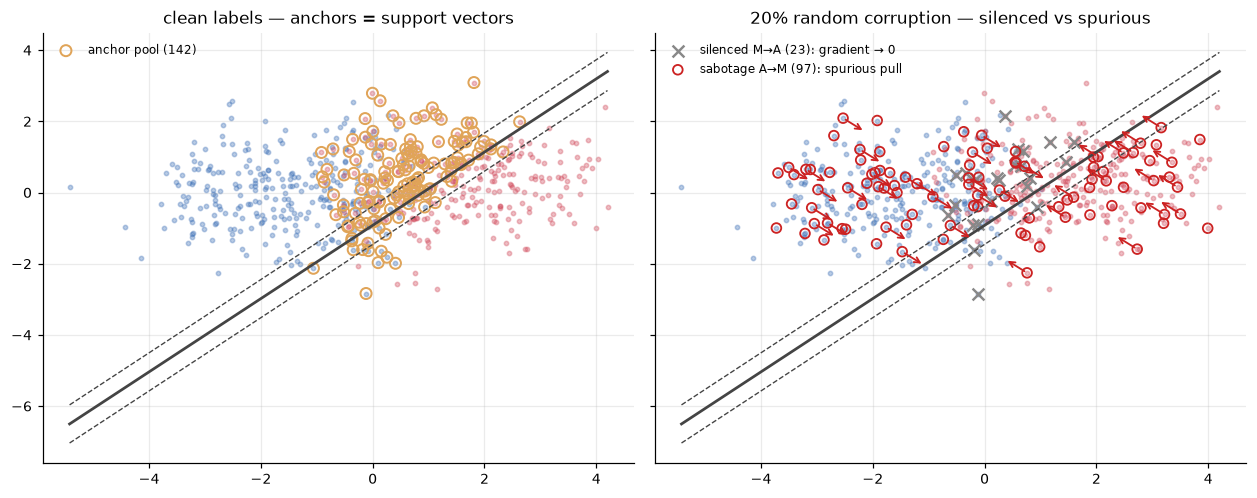

In [2]:

cfg = base_config("genai", seed=SEED)
ds, _ = build_world(cfg)
y = ds.y.copy()
oracle = fit_oracle(ds)
panel = default_panel()
v0 = None
from labelsim.engine import _make_v0
v0 = _make_v0(cfg, ds, oracle)
_, sys0, _ = panel.vote(v0, ds.X, _stream(SEED, "judge", 0))
mis0 = sys0 != y            # misaligned under v0, clean labels

def corrupt(y, mode, frac, seed, sys_votes):
    rng = np.random.default_rng([seed, 777])
    yv = y.copy(); n = len(y)
    if mode == "random":
        pick = rng.choice(n, size=int(round(frac * n)), replace=False)
        yv[pick] = 1 - yv[pick]
    elif mode == "silence":     # M->A: flip misaligned items' labels to the system vote
        pool = np.flatnonzero(sys_votes != y)
        pick = rng.choice(pool, size=int(round(frac * len(pool))), replace=False)
        yv[pick] = sys_votes[pick]
    elif mode == "sabotage":    # A->M: flip aligned items' labels
        pool = np.flatnonzero(sys_votes == y)
        pick = rng.choice(pool, size=int(round(frac * len(pool))), replace=False)
        yv[pick] = 1 - yv[pick]
    return yv, np.flatnonzero(yv != y), pick

yv, changed, _ = corrupt(y, "random", 0.2, SEED, sys0)
sil = np.array([i for i in changed if mis0[i] and yv[i] == sys0[i]])
sab = np.array([i for i in changed if not mis0[i]])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharex=True, sharey=True)
for ax, title, show_corr in ((axes[0], "clean labels — anchors = support vectors", False),
                             (axes[1], "20% random corruption — silenced vs spurious", True)):
    for c, col in ((0, C0), (1, C1)):
        mk = y == c
        ax.scatter(ds.X[mk, 0], ds.X[mk, 1], s=8, alpha=.35, color=col)
    w, b = v0.w, v0.b; nw = np.linalg.norm(w)
    xs = np.linspace(ds.X[:,0].min(), ds.X[:,0].max(), 50)
    for off, lw, ls in ((0, 1.8, "-"), (1, .9, "--"), (-1, .9, "--")):
        ax.plot(xs, -(w[0]*xs + b - off) / w[1], ls, color="#444", lw=lw)
    if not show_corr:
        anch = np.flatnonzero(mis0)
        ax.scatter(ds.X[anch,0], ds.X[anch,1], s=52, facecolors="none",
                   edgecolors="#e0a458", linewidths=1.3, label=f"anchor pool ({len(anch)})")
    else:
        if len(sil):
            ax.scatter(ds.X[sil,0], ds.X[sil,1], s=60, marker="x", color="#888",
                       linewidths=1.6, label=f"silenced M→A ({len(sil)}): gradient → 0")
        n_hat = w / nw
        for i in sab[:40]:
            tgt = 1 if yv[i] == 1 else -1
            ax.annotate("", xy=ds.X[i] + 0.55 * tgt * n_hat, xytext=ds.X[i],
                        arrowprops=dict(arrowstyle="->", color="#c22", lw=1.2))
        ax.scatter(ds.X[sab,0], ds.X[sab,1], s=40, facecolors="none", edgecolors="#c22",
                   linewidths=1.2, label=f"sabotage A→M ({len(sab)}): spurious pull")
    ax.set_title(title); ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
print(f"under v0: {mis0.sum()} misaligned items; corruption changed {len(changed)} labels "
      f"-> {len(sil)} silenced, {len(sab)} spurious")


## 4 · Chaotic descent, visualized

Left: eight seeds' trajectories in the $(\varphi, d)$ policy plane (offsets relative to each
world's oracle), clean vs 30% sabotage — the corrupted runs fan out. Right: the per-step
direction test — cosine between each ACCEPTED step $\Delta\theta_k$ and the true full-batch
descent direction $-\nabla L(\theta_k)$ (clean labels). Clean runs step with the true gradient;
sabotage pushes mass to zero and negative cosines: descent in chaotic directions.


median step-cosine: clean +0.07  sabotage +0.04  | negative-direction steps: clean 46%, sabotage 47%


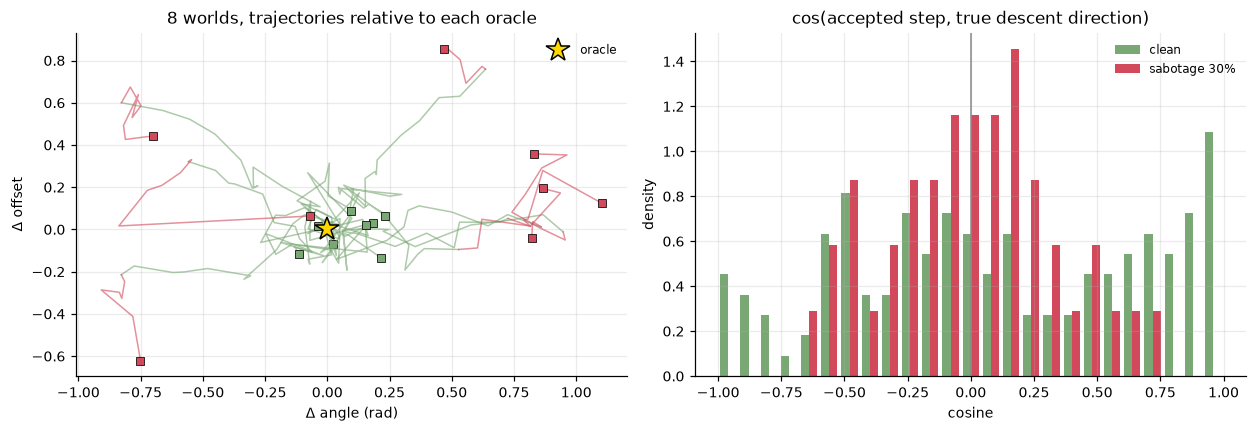

In [3]:

def logistic_grad(pol, X, yy):
    p = 1/(1+np.exp(-np.clip(X @ pol.w + pol.b, -30, 30)))
    err = p - yy
    return np.concatenate([err @ X / len(yy), [err.mean()]])

def run_variant(seed, mode, frac):
    cfg = base_config("genai", seed=seed, cycles=30)
    ds, _ = build_world(cfg)
    y = ds.y.copy(); oracle = fit_oracle(ds)
    v0 = _make_v0(cfg, ds, oracle)
    _, sys0, _ = default_panel().vote(v0, ds.X, _stream(seed, "judge", 0))
    if mode == "clean":
        labels = (y.copy(), np.zeros(ds.n, bool))
    else:
        yv, changed, _ = corrupt(y, mode, frac, seed, sys0)
        fl = np.zeros(ds.n, bool); fl[changed] = True
        labels = (yv, fl)
    return ds, run_crank(cfg, ds=ds, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
cosines = {"clean": [], "sabotage 30%": []}
for mode, frac, col, lab in (("clean", 0, "#7aa874", "clean"),
                             ("sabotage", 0.3, "#d1495b", "sabotage 30%")):
    for s in range(8):
        seed = SEED + 100*s
        ds_s, res = run_variant(seed, mode, frac)
        orc = res["oracle"]
        po, do_ = np.arctan2(orc.w[1], orc.w[0]), -orc.b/np.linalg.norm(orc.w)
        tp = [np.arctan2(p.w[1], p.w[0]) - po for p in res["snapshots"]]
        td = [(-p.b/np.linalg.norm(p.w)) - do_ for p in res["snapshots"]]
        axes[0].plot(tp, td, color=col, lw=1.0, alpha=.6)
        axes[0].plot(tp[-1], td[-1], "s", color=col, ms=5, mec="k", mew=.5)
        snaps = res["snapshots"]; acc = res["series"]["accepted"]
        for k in range(1, len(snaps)):
            if not acc[k]:
                continue
            dth = np.concatenate([snaps[k].w - snaps[k-1].w, [snaps[k].b - snaps[k-1].b]])
            g = -logistic_grad(snaps[k-1], ds_s.X, ds_s.y.astype(float))
            denom = np.linalg.norm(dth) * np.linalg.norm(g)
            if denom > 1e-12:
                cosines[lab].append(float(dth @ g / denom))
axes[0].plot(0, 0, "*", color="gold", ms=16, mec="k", label="oracle")
axes[0].set(title="8 worlds, trajectories relative to each oracle",
            xlabel="Δ angle (rad)", ylabel="Δ offset")
axes[0].legend(fontsize=8)
axes[1].hist([cosines["clean"], cosines["sabotage 30%"]], bins=25,
             color=["#7aa874", "#d1495b"], label=["clean", "sabotage 30%"], density=True)
axes[1].axvline(0, color="#888", lw=1)
axes[1].set(title="cos(accepted step, true descent direction)", xlabel="cosine",
            ylabel="density")
axes[1].legend(fontsize=8)
plt.tight_layout()
print(f"median step-cosine: clean {np.median(cosines['clean']):+.2f}  "
      f"sabotage {np.median(cosines['sabotage 30%']):+.2f}  | "
      f"negative-direction steps: clean {np.mean(np.array(cosines['clean'])<0):.0%}, "
      f"sabotage {np.mean(np.array(cosines['sabotage 30%'])<0):.0%}")


## 5 · Anchor-targeted corruption: silence vs sabotage vs random

The suite version of §3–4, at 10 / 20 / 50% of the respective pools (6 seeds; genai, 30 cycles).
`silence` removes learning signal (expect slower/lower convergence, no chaos); `sabotage` injects
wrong signal (expect damage + spread); `random` is the mixture the demo assumes and the real runs
will calibrate.


silence   final F1  10%: 0.894±0.005  20%: 0.892±0.005  50%: 0.873±0.016
sabotage  final F1  10%: 0.870±0.015  20%: 0.841±0.039  50%: 0.489±0.248
random    final F1  10%: 0.875±0.022  20%: 0.856±0.018  50%: 0.426±0.206


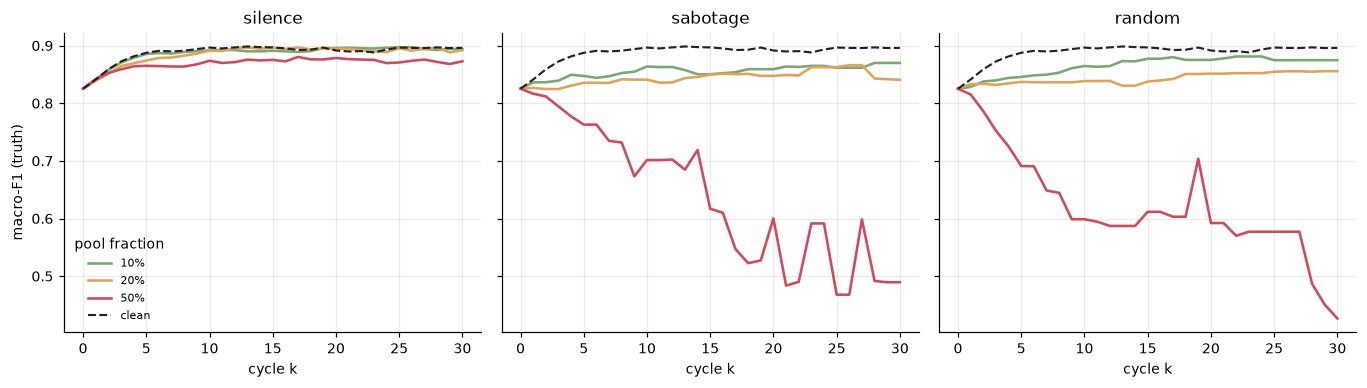

In [4]:

MODES = ("silence", "sabotage", "random")
FRACS = (0.1, 0.2, 0.5)
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6), sharey=True)
summary = {}
for ax, mode in zip(axes, MODES):
    for frac, col in zip(FRACS, ("#7aa874", "#e0a458", "#d1495b")):
        curves = []
        for s in range(6):
            _, res = run_variant(SEED + 100*s, mode, frac)
            curves.append(res["series"]["policy_f1_true"])
        m = np.mean(np.array(curves), axis=0)
        ax.plot(range(len(m)), m, color=col, lw=1.7, label=f"{int(frac*100)}%")
        summary[(mode, frac)] = mean_ci([c[-1] for c in curves])
    cl = []
    for s in range(6):
        _, res = run_variant(SEED + 100*s, "clean", 0)
        cl.append(res["series"]["policy_f1_true"])
    mcl = np.mean(np.array(cl), axis=0)
    ax.plot(range(len(mcl)), mcl, color="#222", lw=1.4, ls="--", label="clean")
    ax.set(title=f"{mode}", xlabel="cycle k")
axes[0].set_ylabel("macro-F1 (truth)")
axes[0].legend(fontsize=7.5, title="pool fraction")
plt.tight_layout()
for mode in MODES:
    row = "  ".join(f"{int(f*100)}%: {summary[(mode,f)][0]:.3f}±{summary[(mode,f)][1]:.3f}"
                    for f in FRACS)
    print(f"{mode:9s} final F1  {row}")


## 6 · Interactive sandbox

Sliders re-run a small world live (ipywidgets; falls back to instructions on a static render —
GitHub does not execute widgets, run this cell in Jupyter).


In [5]:

try:
    import ipywidgets as W
    from IPython.display import display

    def explore(mode="sabotage", frac=0.3, seed=13):
        ds_i, res = run_variant(int(seed), mode if frac > 0 else "clean", frac)
        _, res_c = run_variant(int(seed), "clean", 0)
        fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
        axes[0].plot(res_c["series"]["policy_f1_true"], color="#222", ls="--", label="clean twin")
        axes[0].plot(res["series"]["policy_f1_true"], color="#d1495b", label=f"{mode} {frac:.0%}")
        axes[0].set(title="learning curve (truth)", xlabel="cycle"); axes[0].legend(fontsize=8)
        div = divergence_series(res, res_c)
        axes[1].plot(div["decision_disagreement"], color="#222")
        axes[1].set(title="divergence from clean twin", xlabel="cycle",
                    ylabel="decision disagreement")
        plt.tight_layout(); plt.show()

    W.interact(explore,
               mode=W.Dropdown(options=["random", "silence", "sabotage"], value="sabotage"),
               frac=W.FloatSlider(min=0.0, max=0.6, step=0.05, value=0.3),
               seed=W.IntSlider(min=13, max=913, step=100, value=13))
except ImportError:
    print("ipywidgets not installed — pip install ipywidgets, then re-run this cell.")

interactive(children=(Dropdown(description='mode', index=2, options=('random', 'silence', 'sabotage'), value='…


## 7 · Real runs: corrupted vs clean, through the same lenses

Once the run-corruption option lands in the UX (`corrupt labels: rate x mode {random, anchors}`),
point this loader at one or more clean and corrupted experiment IDs. It plots learning curves,
policy-document growth, and document-space distances — TF-IDF cosine by default (deterministic,
offline); swap `embed()` for an LM Studio embedding model for semantic distances. Until corrupted
runs exist, it demos on whatever local runs it finds.


23 local runs found - demoing on the last two
exp-20260710T153536-4f6e7d: final v0.1  len 14,851 chars  doc-similarity to v0: 1.000
exp-20260710T153949-1ea9a1: final v0.1  len 14,851 chars  doc-similarity to v0: 1.000


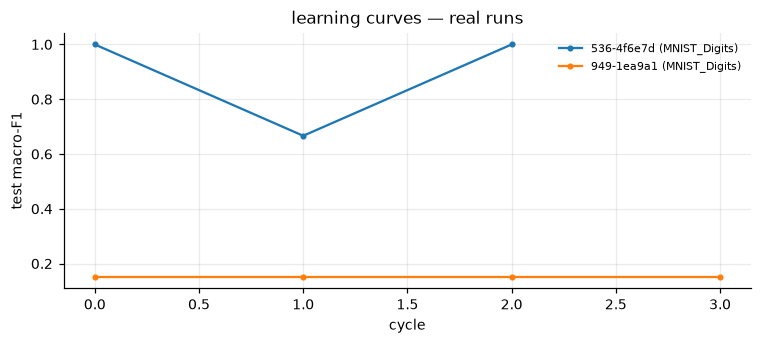

In [6]:

EXP_DIR = Path.cwd().parent.parent.parent / "data" / "experiments"
POLICY_DIR = Path.cwd().parent.parent.parent / "policy-graph"

def load_run(exp_id):
    p = EXP_DIR / exp_id / "experiment.json"
    if not p.exists():
        return None
    s = json.loads(p.read_text())
    f1s = []
    for c in s.get("cycles", []):
        mets = c.get("metrics") or {}
        found = None
        def dig(d):
            nonlocal found
            if isinstance(d, dict):
                for k, v in d.items():
                    if found is None and k == "macro_f1" and isinstance(v, (int, float)):
                        found = v
                    else:
                        dig(v)
        for leg in ("test", "candidate_test", "gate", "panel_test"):
            if leg in mets:
                dig(mets[leg])
                if found is not None:
                    break
        if found is None:
            dig(mets)
        f1s.append(found)
    return {"id": exp_id, "area": s.get("area"), "version": s.get("current_version"),
            "f1": [v for v in f1s if v is not None],
            "config": {k: s.get(k) for k in ("batch_n", "test_n", "epsilon", "seed",
                                             "corrupt_labels", "corrupt_mode") if k in s}}

def tfidf_cos(a: str, b: str) -> float:
    def tf(t):
        words = re.findall(r"[a-z0-9_]+", t.lower())
        d = {}
        for w in words: d[w] = d.get(w, 0) + 1
        return d
    ta, tb = tf(a), tf(b)
    vocab = set(ta) | set(tb)
    idf = {w: math.log(1 + 2 / (1 + (w in ta) + (w in tb))) + 1 for w in vocab}
    va = np.array([ta.get(w, 0) * idf[w] for w in vocab])
    vb = np.array([tb.get(w, 0) * idf[w] for w in vocab])
    n = np.linalg.norm(va) * np.linalg.norm(vb)
    return float(va @ vb / n) if n else float("nan")

def policy_text(area, version):
    d = POLICY_DIR / area / version
    if not d.is_dir():
        return None
    return "\n".join(p.read_text() for p in sorted(d.glob("*.md")))

CLEAN_RUNS, CORRUPT_RUNS = [], []   # <- fill with exp-... ids once corrupted runs exist
available = sorted(p.name for p in EXP_DIR.glob("exp-*")) if EXP_DIR.is_dir() else []
print(f"{len(available)} local runs found", ("- demoing on the last two" if len(available) >= 2
      and not CLEAN_RUNS else ""))
demo = [r for r in (load_run(e) for e in (CLEAN_RUNS + CORRUPT_RUNS or available[-2:])) if r]
if demo:
    fig, ax = plt.subplots(figsize=(7, 3.2))
    for r, col in zip(demo, plt.cm.tab10.colors):
        if r["f1"]:
            ax.plot(range(len(r["f1"])), r["f1"], marker="o", ms=3, color=col,
                    label=f"{r['id'][-10:]} ({r.get('area')})")
    ax.set(title="learning curves — real runs", xlabel="cycle", ylabel="test macro-F1")
    ax.legend(fontsize=7.5)
    plt.tight_layout()
    for r in demo:
        txt = policy_text(r["area"], r["version"]) if r.get("version") else None
        base = policy_text(r["area"], "v0.1") or policy_text(r["area"], "v0.2")
        if txt and base:
            print(f"{r['id']}: final {r['version']}  len {len(txt):,} chars  "
                  f"doc-similarity to v0: {tfidf_cos(txt, base):.3f}")
        else:
            print(f"{r['id']}: policy text not found locally "
                  f"(area={r.get('area')}, version={r.get('version')}) — use "
                  f"/api/policy/render on a machine that has the run")
else:
    print("no runs loadable here; set CLEAN_RUNS/CORRUPT_RUNS to experiment ids "
          "(or run on the machine that holds data/experiments)")


### What to look for once corrupted runs exist

- **Learning rate**: cycles-to-plateau and accepted-step rate, corrupted vs clean (the sim says
  silence slows, sabotage both slows and destabilizes).
- **Policy growth**: bundle size per cycle — sabotage should force clause churn (edits that fight
  each other), silence should under-grow.
- **Document distance**: $d_\varphi(v_k, v_0)$ per run and $d_\varphi(v^{corrupt}_k, v^{clean}_k)$
  across the pair, against the same-seed clean-vs-clean noise floor — with $d_D$ on the fixed
  benchmark as the decision-space ground truth.
- The UX option to build: `corrupt labels` (rate; mode `random` or `anchors` = tier-1/2 targeted;
  seeded, in-memory for the run only — never written to the label store or benchmark; recorded in
  the run manifest for provenance).
